In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import tabulate
import seaborn as sns
from pandas.conftest import as_index

## To Dos:
We can calculate some ratios based on Spend
|ratio|definition|
|--|--|
|cost per subscription|Subscriber / Marketing Spendings|
|Monthly Conversion Rate| Monthly Paid Conversions / Monthly Conversions|
|Yearly Conversion Rate| Yearly Paid Conversions / Yearly Conversions|

# Insights
- Monthly has a 100% conversion Rate
- English Market shows no significant activity until October. The market seems to be in the development phase
- English Market only shows marketing spend from September on
- English Market has the lowest conversion rate and also the lowest absolute conversion count

In [99]:
df = pd.read_excel('202603-case-study-data-analyst-growth.xlsx')
# Type conversions and renaming
df = df.astype({'Business Year':'str'})
df = df.rename(columns={'Marketing Spendings':'Marketing Spending'})
# ratios
df['Cost per Subscription'] = df['Marketing Spending'] / df['Subscriber']
df['Monthly Conversion Rate'] = df['Monthly Paid Conversions'] / df['Monthly Conversions']
df['Yearly Converison Rate'] = df['Yearly Paid Conversions'] / df['Yearly Conversions']

# renaming
df.dtypes

row_num                        int64
Business Year                    str
Business Month                 int64
Market                           str
Conversion Channel 1             str
Conversion Channel 2             str
Conversion Channel 3             str
Marketing Spending             int64
Subscriber                     int64
Monthly Conversions          float64
Yearly Conversions           float64
Share Coupon Used            float64
Share Student Coupon Used    float64
Monthly Paid Conversions       int64
Yearly Paid Conversions      float64
New Revenue Create Date      float64
New Revenue Invoice Date     float64
Cost per Subscription        float64
Monthly Conversion Rate      float64
Yearly Converison Rate       float64
dtype: object

| row name                        | type    |
|---------------------------------|---------|
| row_num                         | int64   |
| Business Year                   | str     |
 Business Month                  | str     |
 Market                          | str     |
 Conversion Channel 1            | str     |
 Conversion Channel 2            | str     |
 Conversion Channel 3            | str     |
 Marketing Spending             | int64   |
 Subscriber                      | int64   |
 Monthly Conversions             | float64 |
 Yearly Conversions              | float64 |
 Share Coupon Used               | float64 |
 Share Student Coupon Used       | float64 |

|Conversion Channel 1| Conversion Channel 1  |Conversion Channel 1| Count|
|--|-----------------------|--|--|
|Non-Paid|  Organic| Direct |48|
| Non-Paid| Organic| IG Channel                      | 48                    |
| Non-Paid| Organic| Newsletter                      | 48                    |
| Non-Paid| Organic| Organic Search                  | 48                    |
| Non-Paid| Organic| PR                              | 48                    |
| Non-Paid| Organic| Pinterest Channel               | 48                    |
| Non-Paid| Organic| TikTok Channel                  | 48                    |
| Non-Paid| Organic| Word of Mouth                   | 48                    |
| Non-Paid| Organic| YT Channel                      | 48                    |
| Non-Paid| Organic| femtasy Podcast                 | 48                    |
| Non-Paid| Other Non-Paid| EIS                      | 48                    |
| Non-Paid| Other Non-Paid| Spotify                  | 48                    |
| Paid| Influencer| Influencer Instagram             | 48                    |
| Paid| Influencer| Influencer Podcast               | 48                    |
| Paid| Influencer| Influencer Youtube               | 48                    |
| Paid| Performance Marketing| Facebook/Instagram Ads | 48                    |
| Paid| Performance Marketing| Google Ads            | 48                    |
| Paid| Performance Marketing| Partnership Ads       | 48                    |
| Paid| Performance Marketing| Pinterest Ads         | 48                    |
| Paid| Performance Marketing| Porn Sites            | 48                    |
| Paid| Performance Marketing| Snapchat Ads          | 48                    |
| Paid| Performance Marketing| TikTok Ads            | 48                    |
| Paid| Performance Marketing| Youtube Ads           | 48                    |
| UNKNOWN| UNKNOWN| UNKNOWN                          | 48                    |

In [198]:
# market_spend = df.groupby(['Market'])[['Marketing Spending']].sum()

# market_spend['Total Spend'] = market_spend['Marketing Spending'].sum()
# market_spend['Spend Share'] = market_spend['Marketing Spending'] / market_spend['Total Spend']

# market_spend["Marketing Spending"] = market_spend["Marketing Spending"].map("{:,}".format)
# market_spend["Spend Share"] = market_spend["Spend Share"].map("{:.1%}".format)

# market_spend[['Marketing Spending','Spend Share']]
market_spend = df.groupby(['Market', 'Business Month'], as_index=False)[['Marketing Spending']].sum()

market_spend.pivot_table(index='Business Month',columns='Market',values='Marketing Spending',aggfunc=sum)
# market_spend.pivot_table(index='Business Month',columns='Market',values='Marketing Spending',aggfunc=sum).plot()

Market,English,French,German,UNKNOWN
Business Month,,,,
1,0,141059,206753,0
2,0,154913,222627,0
3,0,153137,227978,0
4,0,143754,266184,0
5,0,151028,237124,0
6,0,175746,320901,0
7,0,207260,333792,0
8,0,267522,342230,0
9,23156,230612,274193,0


Marketing Spend for 2024

|Market|Marketing Spend € |Spend Share % |
|--|--|--|
|English|380,497|6.4%|
|French|2,257,505|38.0%|
|German|3,309,947|55.6%|
|Unknown|0|0.0%|


# Paid Conversions vs Conversions

In [115]:
monthly_conversions = df.groupby(['Market','Business Month','Conversion Channel 1'], as_index= False)[['Monthly Conversions','Monthly Paid Conversions']].sum()
yearly_conversions = df.groupby(['Market','Business Month','Conversion Channel 1'], as_index= False)[['Yearly Conversions','Yearly Paid Conversions']].sum()

monthly_conversions['Conversion Rate'] = monthly_conversions['Monthly Paid Conversions']/monthly_conversions['Monthly Conversions']
yearly_conversions['Conversion Rate'] = yearly_conversions['Yearly Paid Conversions']/yearly_conversions['Yearly Conversions']

<Axes: xlabel='Market-Conversion Channel 1', ylabel='Business Month'>

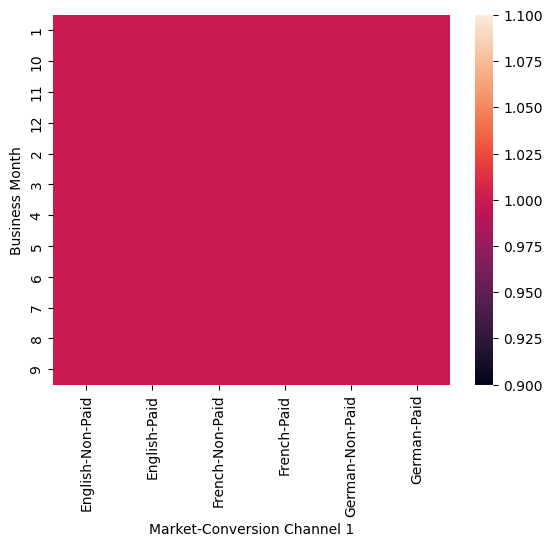

In [85]:
monthly_conversions_rate = monthly_conversions.pivot_table(index='Business Month',columns=['Market','Conversion Channel 1'],values='Conversion Rate')

sns.heatmap(data=monthly_conversions_rate)

<Axes: xlabel='Market-Conversion Channel 1', ylabel='Business Month'>

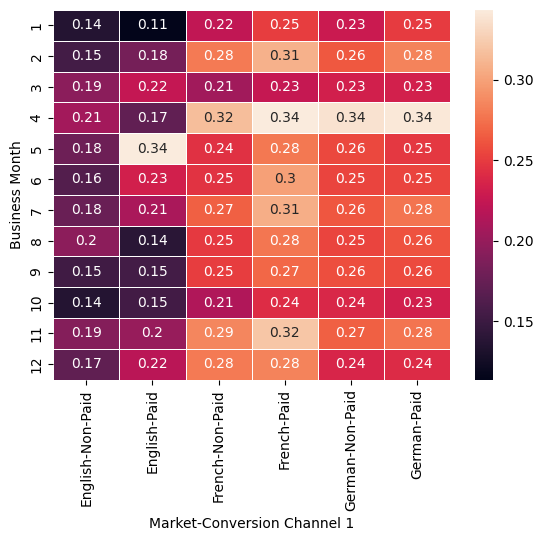

In [101]:
yearly_conversions_rate = yearly_conversions.pivot_table(index='Business Month',columns=['Market','Conversion Channel 1'],values='Conversion Rate')

sns.heatmap(data=yearly_conversions_rate,annot=True, linewidths=.5)

In [209]:
yc_pivot = yearly_conversions[(yearly_conversions['Market'] != 'UNKNOWN')&(yearly_conversions['Conversion Channel 1'] != 'UNKNOWN')]

yc_pivot = yc_pivot.pivot_table(index='Business Month'
                     , columns=['Market','Conversion Channel 1']
                     , values=['Yearly Conversions','Yearly Paid Conversions','Conversion Rate'])

yc_pivot.columns

MultiIndex([(        'Conversion Rate', 'English', 'Non-Paid'),
            (        'Conversion Rate', 'English',     'Paid'),
            (        'Conversion Rate',  'French', 'Non-Paid'),
            (        'Conversion Rate',  'French',     'Paid'),
            (        'Conversion Rate',  'German', 'Non-Paid'),
            (        'Conversion Rate',  'German',     'Paid'),
            (     'Yearly Conversions', 'English', 'Non-Paid'),
            (     'Yearly Conversions', 'English',     'Paid'),
            (     'Yearly Conversions',  'French', 'Non-Paid'),
            (     'Yearly Conversions',  'French',     'Paid'),
            (     'Yearly Conversions',  'German', 'Non-Paid'),
            (     'Yearly Conversions',  'German',     'Paid'),
            ('Yearly Paid Conversions', 'English', 'Non-Paid'),
            ('Yearly Paid Conversions', 'English',     'Paid'),
            ('Yearly Paid Conversions',  'French', 'Non-Paid'),
            ('Yearly Paid Conversions', 

We see that a lot of people start a people sign up for yearly subscriptions. When we look at the Yearly paid Subscriptions though, the conversion Rate, depending on the market, is 34% at its highest. For the german Market the subscription rate is in the mid 20%.

## German

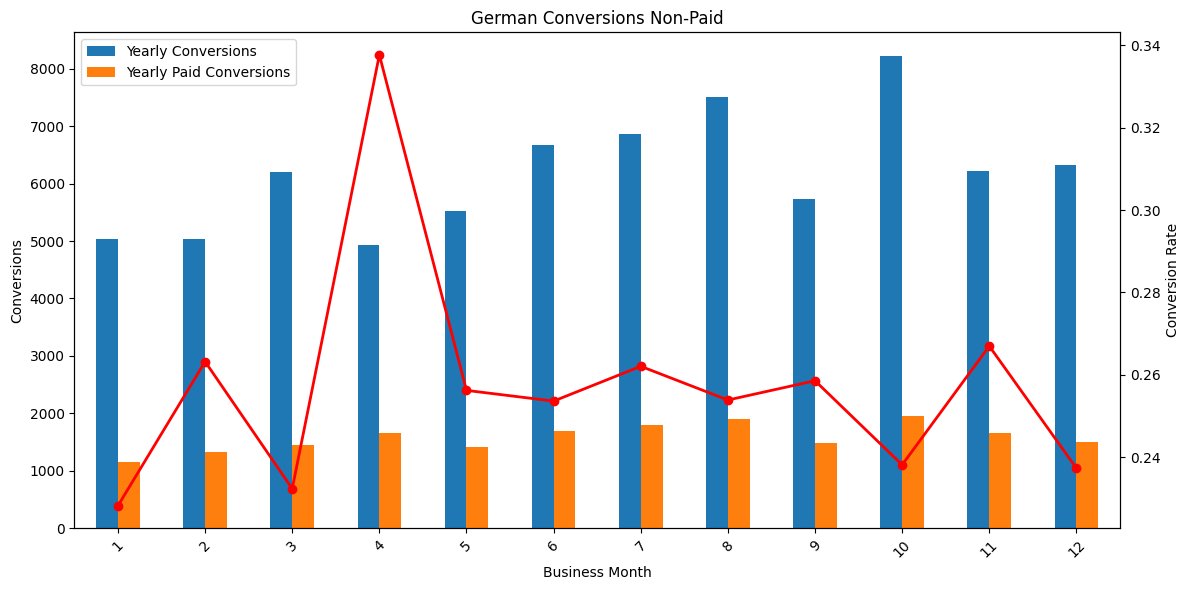

In [135]:
german_non_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'German') &
    (yearly_conversions['Conversion Channel 1'] == 'Non-Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
german_non_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,german_non_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(german_non_paid['Business Month'], rotation=45)

plt.title('German Conversions Non-Paid')

plt.tight_layout()
plt.show()

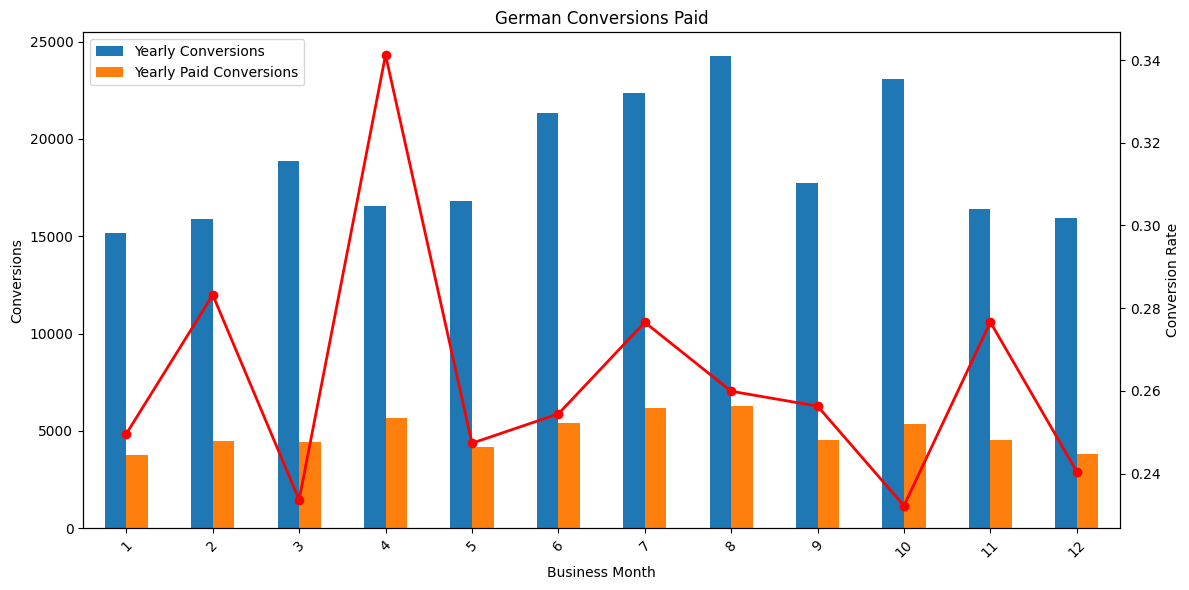

In [136]:
german_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'German') &
    (yearly_conversions['Conversion Channel 1'] == 'Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
german_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,german_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(german_paid['Business Month'], rotation=45)

plt.title('German Conversions Paid')

plt.tight_layout()
plt.show()

## French

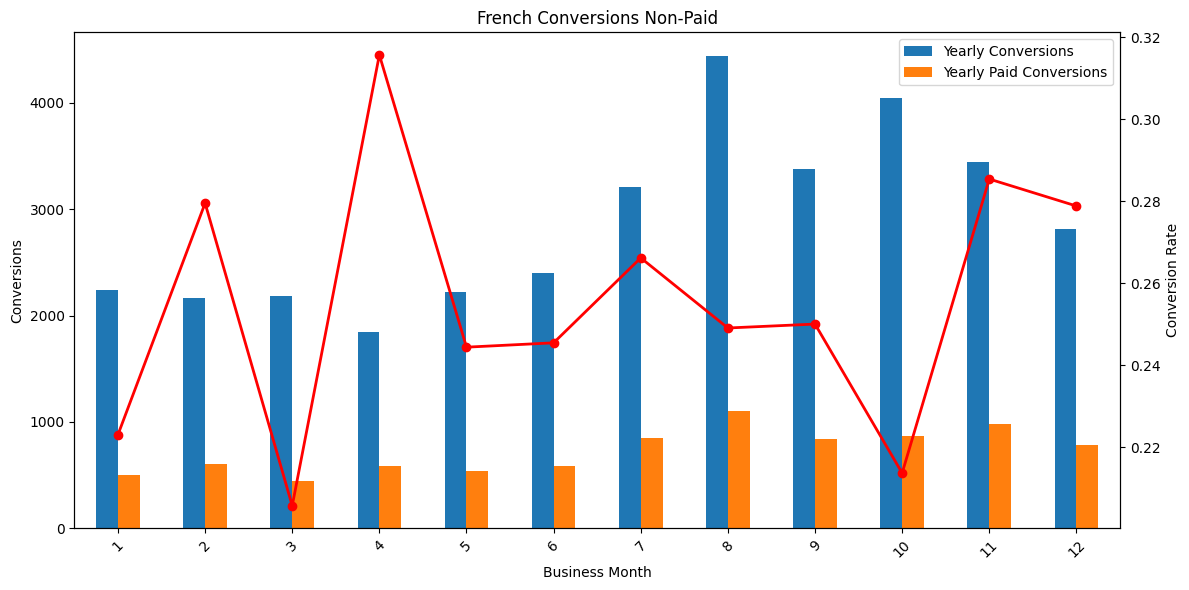

In [140]:
french_non_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'French') &
    (yearly_conversions['Conversion Channel 1'] == 'Non-Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
french_non_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,french_non_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(french_non_paid['Business Month'], rotation=45)

plt.title('French Conversions Non-Paid')

plt.tight_layout()
plt.show()

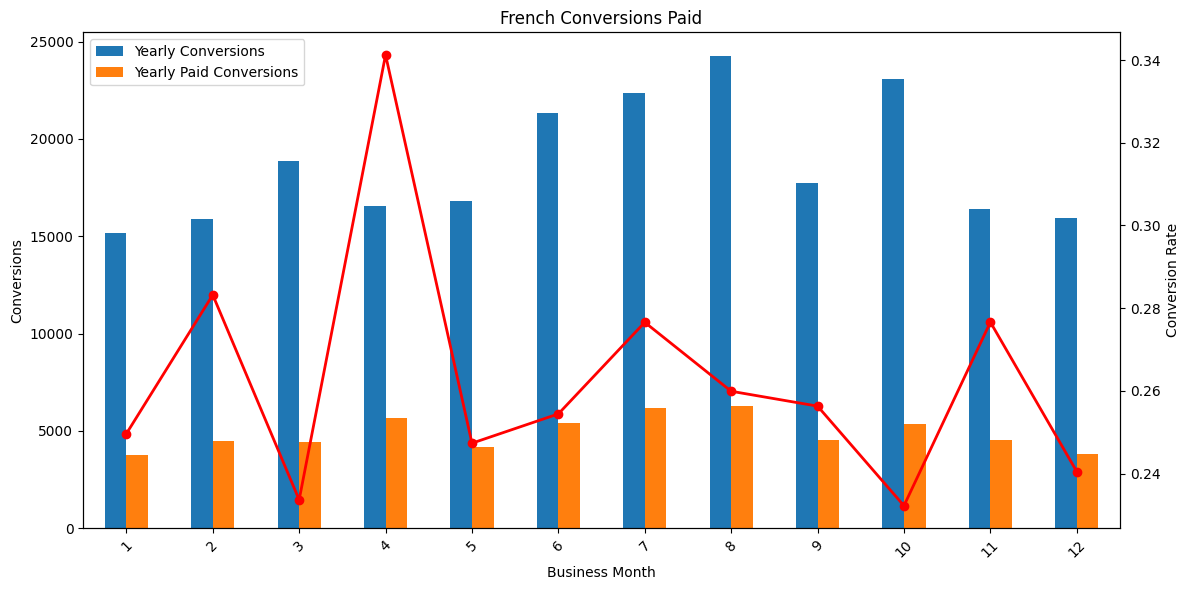

In [139]:
french_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'French') &
    (yearly_conversions['Conversion Channel 1'] == 'Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
german_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,german_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(german_paid['Business Month'], rotation=45)

plt.title('French Conversions Paid')

plt.tight_layout()
plt.show()

## English

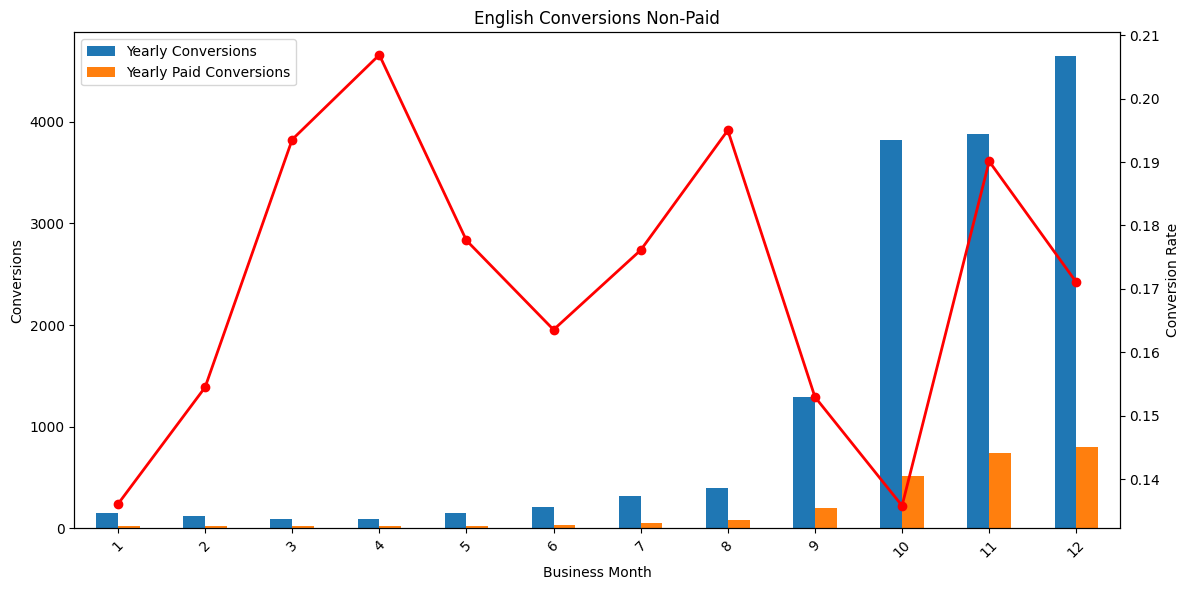

In [143]:
english_non_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'English') &
    (yearly_conversions['Conversion Channel 1'] == 'Non-Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
english_non_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,english_non_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(english_non_paid['Business Month'], rotation=45)

plt.title('English Conversions Non-Paid')

plt.tight_layout()
plt.show()

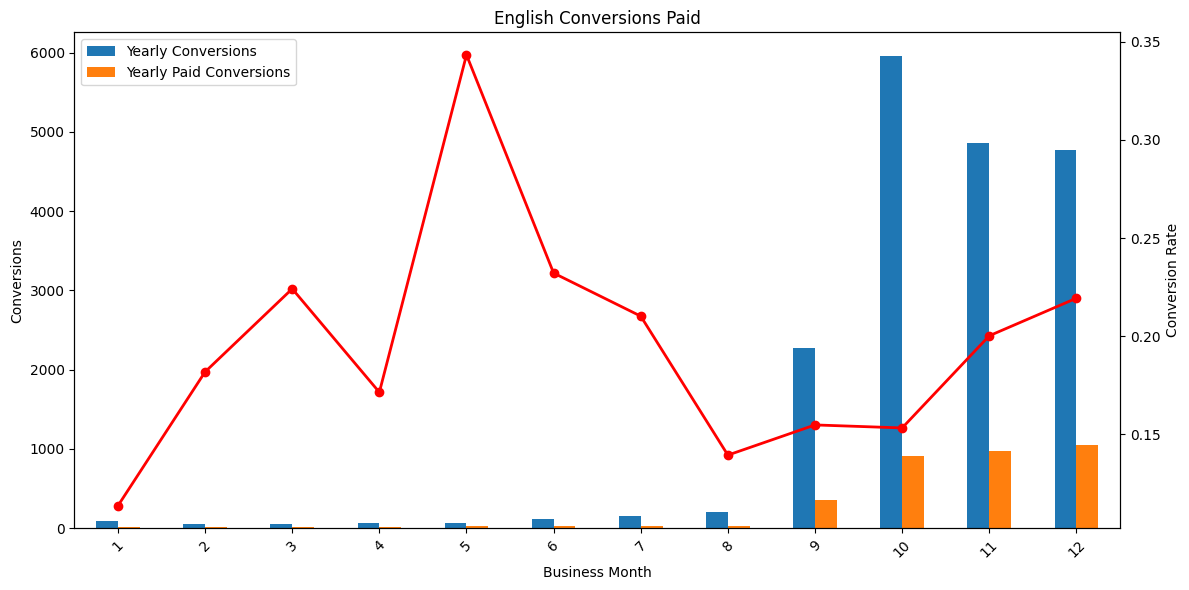

In [142]:
english_paid = yearly_conversions[
    (yearly_conversions['Market'] == 'English') &
    (yearly_conversions['Conversion Channel 1'] == 'Paid')
]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR CHART ---
english_paid.plot(x='Business Month',y=['Yearly Conversions', 'Yearly Paid Conversions'],
    kind='bar',ax=ax1
)

ax1.set_ylabel('Conversions')

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# get x positions used by bar chart
x = [0,1,2,3,4,5,6,7,8,9,10,11]

# plot conversion rate aligned to bars
ax2.plot(x,english_paid['Conversion Rate'],marker='o',color='red',linewidth=2)

ax2.set_ylabel('Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(english_paid['Business Month'], rotation=45)

plt.title('English Conversions Paid')

plt.tight_layout()
plt.show()

# Marketing Spend and Subscriptions

# Insights
## spend
- TikTok has growing number of spend from January to June slowing after that and in October dropping to 0
- Facebook and Instagram is the strongest channel in terms of spend
- google ads is between 2.7k and 10k
- Instagram influencer grows from January throughout the year peaking in October at 174k
- The main Cahnnel is Meta. There is
## subs
- Tiktok was a very effective channel in generating subscriptions per cost unit spent

In [180]:
market_spend = df.groupby(['Business Month','Conversion Channel 1','Conversion Channel 3'],as_index = False)[['Marketing Spending','Subscriber']].sum()

market_spend['Cost Per Sub'] = market_spend['Marketing Spending'] / market_spend['Subscriber']

spend_pivot = market_spend.pivot_table(index=['Conversion Channel 1','Conversion Channel 3'],columns='Business Month',values='Marketing Spending', aggfunc='sum')

subscriber_pivot = market_spend.pivot_table(index=['Conversion Channel 1','Conversion Channel 3'],columns='Business Month',values='Subscriber', aggfunc='sum')

ratio_pivot = market_spend.pivot_table(index=['Conversion Channel 1','Conversion Channel 3'],columns='Business Month',values='Cost Per Sub', aggfunc='sum')

subscriber_pivot

Business Month                                  1      2      3     4      5   \
Conversion Channel 1 Conversion Channel 3                                       
Non-Paid             Direct                   2157   2267   2510  1971   2343   
                     EIS                        44     30     38    40     27   
                     IG Channel               2215   2321   2637  2027   2512   
                     Newsletter                  0      0      0     0      0   
                     Organic Search              0      0      0     0      0   
                     PR                        956    844   1131   862    997   
                     Pinterest Channel           0      0      0     0      0   
                     Spotify                    81     74     69    72     61   
                     TikTok Channel            222    173    223   210    171   
                     Word of Mouth            2232   2094   2306  2048   2328   
                     YT Channel                  0      0      0     0      0   
                     femtasy Podcast           248    263    258   241    278   
Paid                 Facebook/Instagram Ads  10450  10725  12302  9390  10474   
                     Google Ads               2475   2096   2450  2270   2604   
                     Influencer Instagram     8105   9016   9770  9026   9961   
                     Influencer Podcast        201    191    192   187    214   
                     Influencer Youtube          0      0      0     1      0   
                     Partnership Ads             0      0      0     0      0   
                     Pinterest Ads               0      0      0     0      0   
                     Porn Sites                  0      0      0     0      0   
                     Snapchat Ads                0      0      0     0      0   
                     TikTok Ads               2739   2287   2841  3146   2273   
                     Youtube Ads                33     57     77    46     59   
UNKNOWN              UNKNOWN                     0      0      0     0      0   

Business Month                                  6      7      8      9   \
Conversion Channel 1 Conversion Channel 3                                 
Non-Paid             Direct                   2615   3126   3809   2938   
                     EIS                        29     34     31     27   
                     IG Channel               3352   3775   4699   4329   
                     Newsletter                  0      0      0      0   
                     Organic Search              0      0      0      0   
                     PR                        988   1054   1103    926   
                     Pinterest Channel           0      0      0      0   
                     Spotify                    90     92     87     93   
                     TikTok Channel            219    149    186    136   
                     Word of Mouth            2454   2660   2953   2436   
                     YT Channel                  0      0      0      0   
                     femtasy Podcast           294    322    401    312   
Paid                 Facebook/Instagram Ads  13871  17280  21094  16804   
                     Google Ads               1895   1959   2381   2056   
                     Influencer Instagram    12835  13530  16085  12173   
                     Influencer Podcast        187    346    190    185   
                     Influencer Youtube          0      0      0      0   
                     Partnership Ads             0      0      0      0   
                     Pinterest Ads               0      0      0      0   
                     Porn Sites                  0      0      0      0   
                     Snapchat Ads                0      0      0      0   
                     TikTok Ads               2300   1964   1523   1137   
                     Youtube Ads                75     82    112    100   
UNKNOWN           

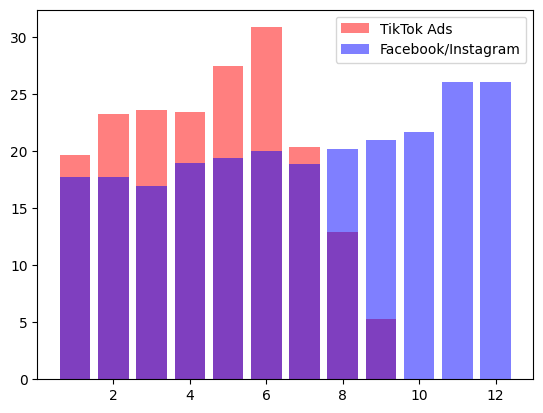

In [173]:
tt = ratio_pivot.loc['TikTok Ads']
fb = ratio_pivot.loc['Facebook/Instagram Ads']

x = [1,2,3,4,5,6,7,8,9,10,11,12]

plt.bar(x,tt,alpha=0.5,color='red',label='TikTok Ads')
plt.bar(x,fb, alpha=0.5,color='blue',label='Facebook/Instagram')
plt.legend()
plt.show()

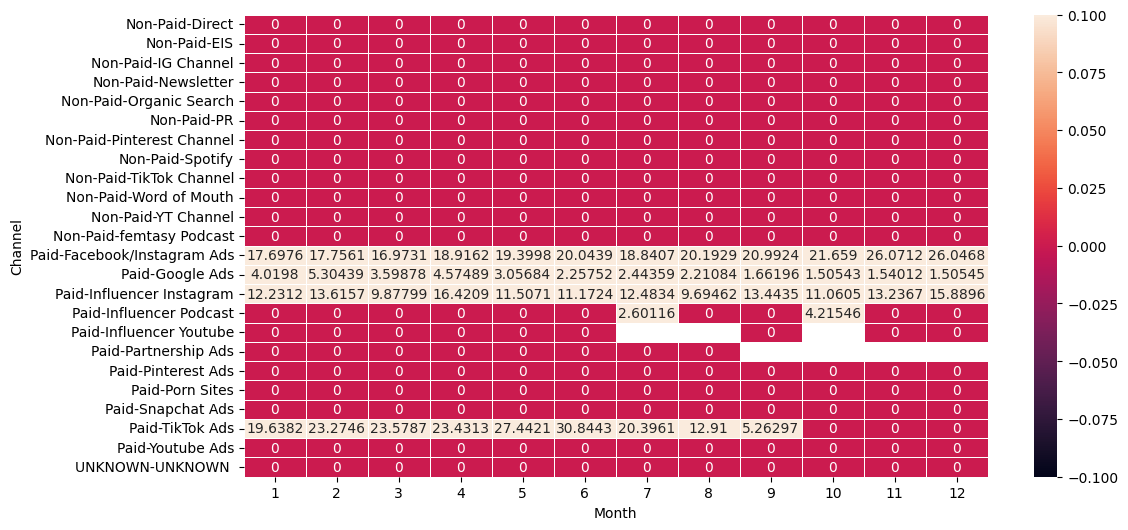

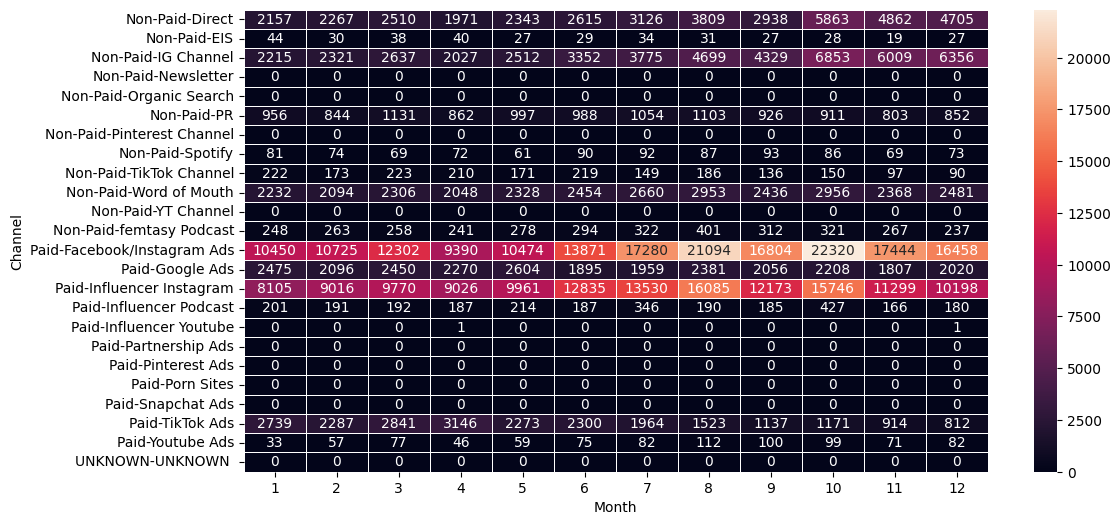

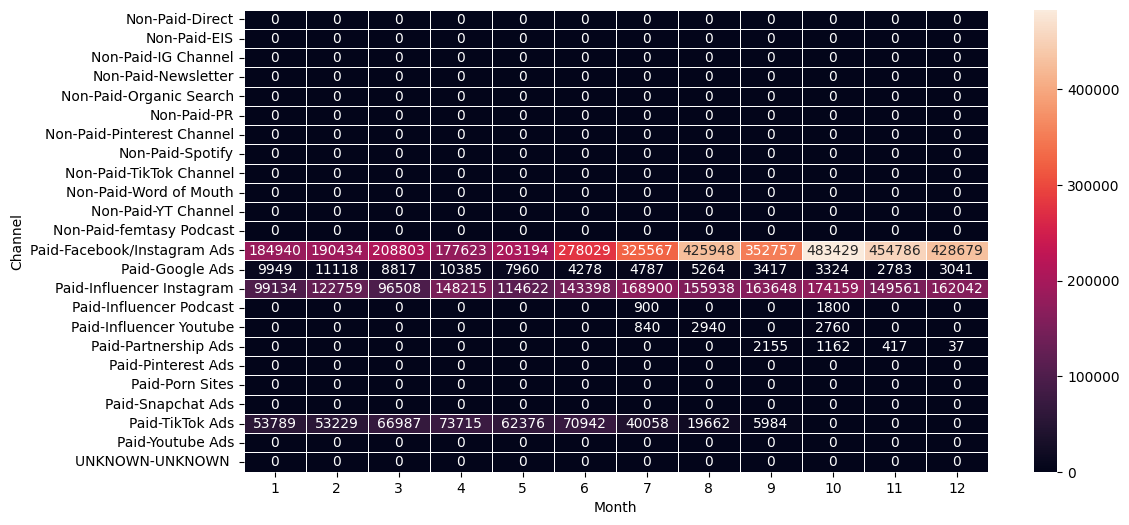

In [194]:
for i in [ratio_pivot,subscriber_pivot,spend_pivot]:
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(data=i,annot=True, linewidths=.5,fmt='g')
    ax.set_ylabel('Channel')
    ax.set_xlabel('Month')
    plt.show()
